- Extended Figure 22

In [ ]:
adatas = [sc.read_h5ad(adata) for adata in ['c2f/Mouse1.h5ad', 'c2f/Mouse2.h5ad', 'c2f/Mouse3.h5ad', 'c2f/Mouse4.h5ad']]
adata = sc.concat(adatas)
adata

AnnData object with n_obs × n_vars = 17937 × 29008
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap'
    layers: 'ambiguous', 'counts', 'log1p', 'matrix', 'spliced', 'unspliced'

In [53]:
adata.write('c2f/combined.h5ad')

# c2f - Concat

In [1]:
import warnings
warnings.filterwarnings('ignore')
import cell2fate as c2f
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/workspace')

Global seed set to 0


In [6]:
!ls

combined_phate.h5ad


In [7]:
adata = sc.read_h5ad('combined_phate.h5ad')
adata.X = adata.layers['counts'].copy()
adata

AnnData object with n_obs × n_vars = 17937 × 29008
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type'
    uns: 'cell_type_colors', 'neighbors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap', 'X_umap_old'
    layers: 'ambiguous', 'counts', 'log1p', 'matrix', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [8]:
clusters_to_remove = []
adata =  c2f.utils.get_training_data(adata, cells_per_cluster = 10**5, cluster_column = 'cell_type', remove_clusters = [],min_shared_counts = 20, n_var_genes= 3000)

Keeping at most 100000 cells per cluster
Filtered out 16956 genes that are detected 20 counts (shared).
Extracted 3000 highly variable genes.


- use batch key

In [9]:
c2f.Cell2fate_DynamicalModel.setup_anndata(adata, spliced_label='spliced', unspliced_label='unspliced', batch_key = 'sample_id') # jax error

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [10]:
n_modules = c2f.utils.get_max_modules(adata)

Leiden clustering ...
         Falling back to preprocessing with `sc.pp.pca` and default params.
Number of Leiden Clusters: 19
Maximal Number of Modules: 21


In [11]:
mod = c2f.Cell2fate_DynamicalModel(adata, n_modules = n_modules)

- 31m 31.2s

In [12]:
mod.train()

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 500/500: 100%|██████████| 500/500 [37:15<00:00,  4.47s/it, v_num=1, elbo_train=5.94e+7]


In [16]:
import dill
# Create a dictionary with the important objects you want to save
save_dict = {
    'mod': mod,
    'n_modules': n_modules,
    'adata': adata  # Note: depending on the size, you might want to save this separately with adata.write()
}

# Save using dill which handles more complex objects than pickle
with open('combined_mod.dill', 'wb') as f:
    dill.dump(save_dict, f)

print("Session objects saved successfully to combined_mod.dill")

Session objects saved successfully to combined_mod.dill


In [17]:
import gc
gc.collect()

2556

In [18]:
adata = mod.export_posterior(adata)

Sampling global variables, sample: 100%|██████████| 29/29 [00:33<00:00,  1.14s/it]


In [19]:
save_dict = {
    'mod': mod,
    'n_modules': n_modules,
    'adata': adata  # Note: depending on the size, you might want to save this separately with adata.write()
}
# Save using dill which handles more complex objects than pickle
with open('combined_mod.dill', 'wb') as f:
    dill.dump(save_dict, f)
print("Session objects saved successfully to combined_mod.dill")

OSError: [Errno 122] Disk quota exceeded

In [20]:
cell_type_colors = {
    'Tumor': '#66c2a5',
    'OPC': '#fc8d62',
    'COP': '#8da0cb'
}
adata.uns['cell_type_colors'] = [cell_type_colors[ct] for ct in adata.obs['cell_type'].cat.categories]


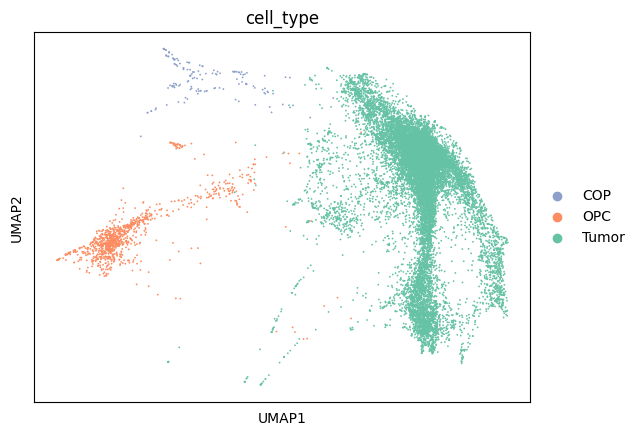

In [21]:
sc.pl.umap(adata, color = 'cell_type')

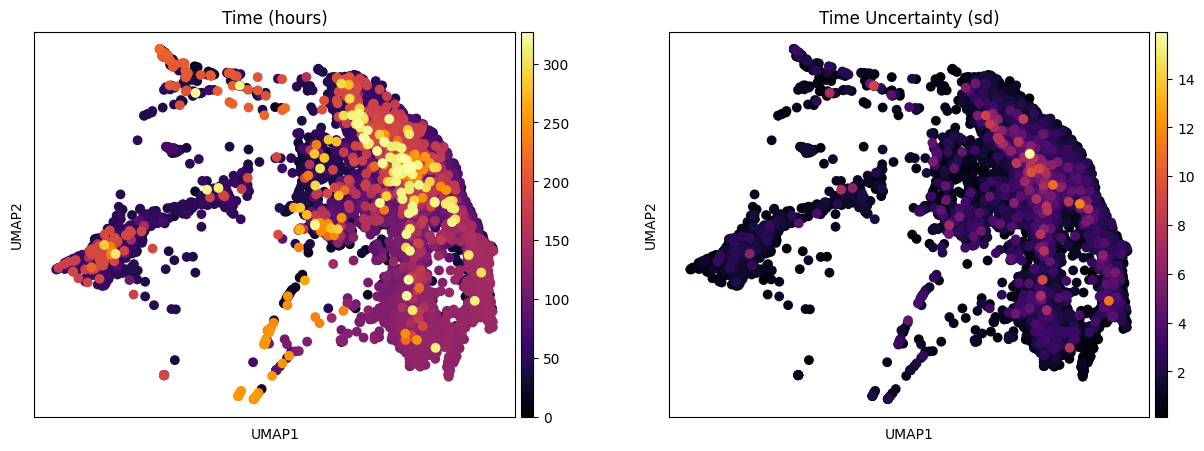

In [13]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
sc.pl.umap(adata, color = ['Time (hours)'], legend_loc = 'right margin',
                size = 200, color_map = 'inferno', ncols = 2, show = False, ax = ax[0])
sc.pl.umap(adata, color = ['Time Uncertainty (sd)'], legend_loc = 'right margin',
                size = 200, color_map = 'inferno', ncols = 2, show = False, ax = ax[1])
plt.savefig('UMAP_Time_nModules' + str(n_modules) + '.pdf')

In [22]:
adata = mod.compute_module_summary_statistics(adata)

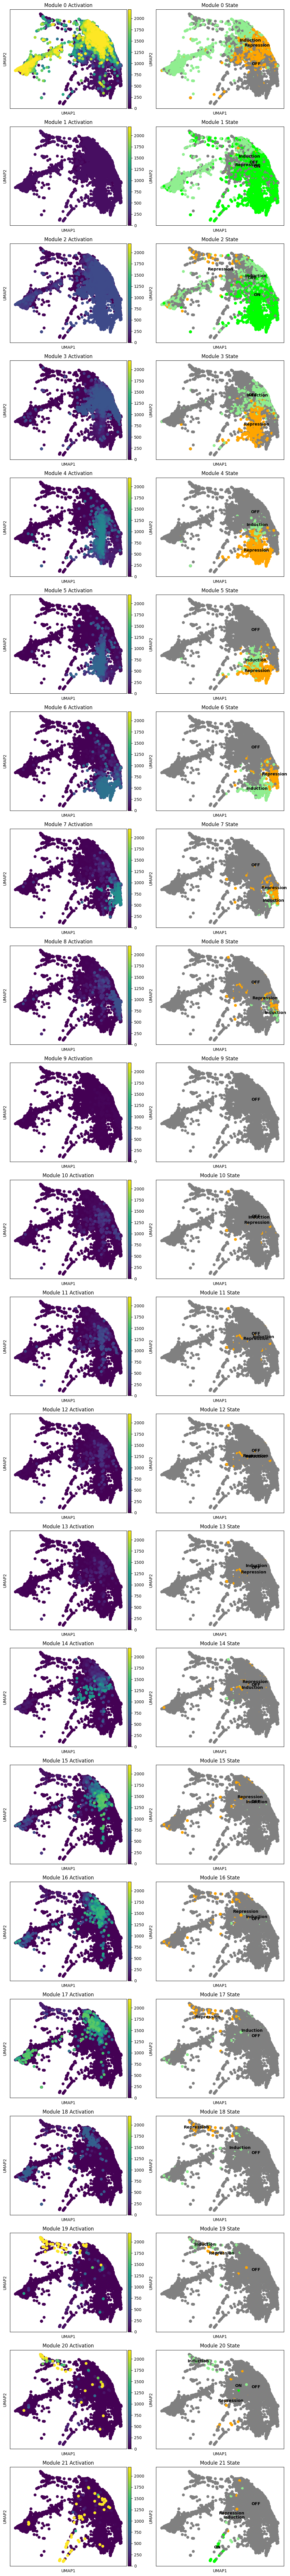

In [15]:
mod.plot_module_summary_statistics(adata, save = 'module_summary_stats_plot.pdf')

In [23]:
adata.obs.to_csv('combined.csv')

- 54분 돌렸는데도 안돌아감 (17000 cells)

In [16]:
mod.compute_and_plot_total_velocity(adata, save = 'total_velocity_plots.png', delete = False, plotting_kwargs = {"color": 'cell_type'})

Computing total RNAvelocity ...


KeyboardInterrupt: 

Computing total RNAvelocity ...


  0%|          | 0/17937 [00:00<?, ?cells/s]

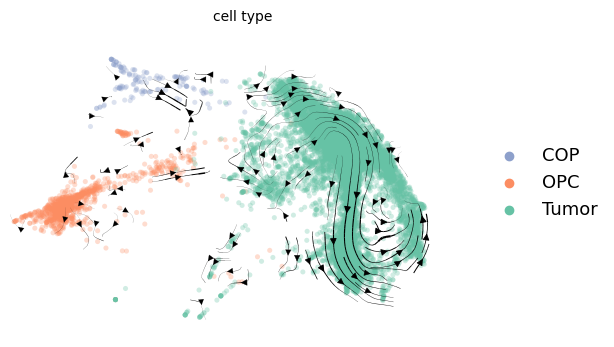

In [24]:
mod.compute_and_plot_total_velocity_scvelo(adata, save = 'total_velocity_plots.svg', delete = False, plotting_kwargs = {"color": 'cell_type', 'legend_loc' : 'right margin', 'legend_fontsize' : 13})

In [26]:
adata

AnnData object with n_obs × n_vars = 17937 × 3000
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type', '_indices', '_scvi_batch', 'Time (hours)', 'Time Uncertainty (sd)', 'Module 0 Activation', 'Module 0 State', 'Module 1 Activation', 'Module 1 State', 'Module 2 Activation', 'Module 2 State', 'Module 3 Activation', 'Module 3 State', 'Module 4 Activation', 'Module 4 State', 'Module 5 Activation', 'Module 5 State', 'Module 6 Activation', 'Modu

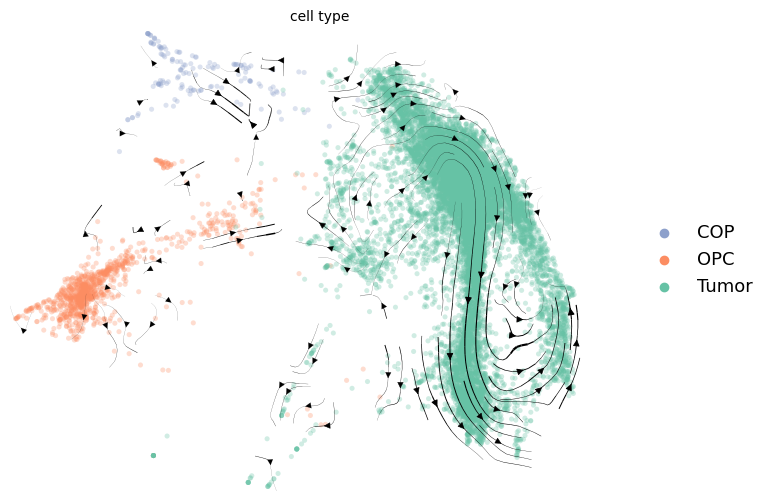

In [27]:
import scvelo as scv
fix, ax = plt.subplots(1, 1, figsize = (8, 6))
scv.pl.velocity_embedding_stream(adata, basis='umap', save = False, vkey='velocity',color= 'cell_type', legend_loc = 'right margin',
                                 show = False, ax = ax, legend_fontsize = 13)
plt.savefig('total_velocity_plots_scvpl.svg', bbox_inches = 'tight', dpi = 300)